# 04 — Deep Learning, MLP (PyTorch & Keras)

Two parallel implementations of the same architecture, trained on the
scaled wallet-level feature matrix from notebook 02:

```
Input(F)  →  Dense(64) + BN + ReLU + Dropout(0.3)
          →  Dense(32) + BN + ReLU + Dropout(0.3)
          →  Dense(1, sigmoid)
```

Class imbalance handled with a positive-class weight in BCE loss.
Trained with Adam, early stopping on validation F1.


## Imports & setup


In [1]:
import sys, pathlib, os, warnings, time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import tensorflow as tf
from tensorflow import keras

from rexell_ml import data, features, metrics

data.set_seed(42)

MODELS_DIR = pathlib.Path("..") / "models"
REPORTS_DIR = pathlib.Path("..") / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "device:", DEVICE)
print("tf   :", tf.__version__)


torch: 2.11.0+cu130 device: cpu
tf   : 2.17.1


## Load split + scale features


In [2]:
split = data.load_split("master_features")
scaler, X_tr, X_va, X_te = features.normalize(
    split.X_train, split.X_val, split.X_test
)
n_features = X_tr.shape[1]
pos_weight = float((split.y_train == 0).sum() / max((split.y_train == 1).sum(), 1))
print("features :", n_features, " pos_weight:", round(pos_weight, 2))
for name, shape in split.shapes().items():
    print(f"  {name:>5}:  {shape}")


features : 30  pos_weight: 60.14
  train:  (2996, 30)
    val:  (643, 30)
   test:  (643, 30)


## 4.1 — PyTorch MLP

Built with `torch.nn.Sequential`, trained with manual loop so we can
early-stop on validation F1 and keep the best weights.


In [3]:
class TorchMLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


torch_model = TorchMLP(n_features).to(DEVICE)
print(torch_model)


TorchMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [4]:
from sklearn.metrics import f1_score

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_tr.values, dtype=torch.float32),
        torch.tensor(split.y_train.values, dtype=torch.float32),
    ),
    batch_size=256, shuffle=True, drop_last=False,
)

X_val_t = torch.tensor(X_va.values, dtype=torch.float32, device=DEVICE)
y_val_np = split.y_val.values

opt = torch.optim.Adam(torch_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))

history = {"train_loss": [], "val_f1": [], "val_auc": []}
best_state, best_f1, patience, max_patience, max_epochs = None, -1, 0, 8, 60

from sklearn.metrics import roc_auc_score
t0 = time.time()
for epoch in range(1, max_epochs + 1):
    torch_model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = torch_model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        ep_loss += float(loss) * len(xb)
    ep_loss /= len(train_loader.dataset)

    torch_model.eval()
    with torch.no_grad():
        p_val = torch.sigmoid(torch_model(X_val_t)).cpu().numpy()
    val_f1 = float(f1_score(y_val_np, (p_val >= 0.5).astype(int), zero_division=0))
    val_auc = float(roc_auc_score(y_val_np, p_val)) if len(np.unique(y_val_np)) > 1 else float("nan")
    history["train_loss"].append(ep_loss)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.clone().detach() for k, v in torch_model.state_dict().items()}
        patience = 0
    else:
        patience += 1

    if epoch == 1 or epoch % 5 == 0 or patience >= max_patience:
        print(f"  epoch {epoch:>3d}  loss={ep_loss:.4f}  val_F1={val_f1:.4f}  val_AUC={val_auc:.4f}")

    if patience >= max_patience:
        print(f"  -> early stopping at epoch {epoch} (best F1 {best_f1:.4f})")
        break

torch_model.load_state_dict(best_state)
print(f"trained in {time.time()-t0:.1f}s  best val F1 = {best_f1:.4f}")


  epoch   1  loss=1.3968  val_F1=0.9474  val_AUC=1.0000
  epoch   5  loss=0.4840  val_F1=0.8696  val_AUC=1.0000


  epoch  10  loss=0.3391  val_F1=1.0000  val_AUC=1.0000
  -> early stopping at epoch 10 (best F1 1.0000)
trained in 0.5s  best val F1 = 1.0000


In [5]:
# Final eval on val + test.
torch_model.eval()
with torch.no_grad():
    X_te_t = torch.tensor(X_te.values, dtype=torch.float32, device=DEVICE)
    p_val = torch.sigmoid(torch_model(X_val_t)).cpu().numpy()
    p_test = torch.sigmoid(torch_model(X_te_t)).cpu().numpy()

m_val_torch = metrics.evaluate(split.y_val.values, p_val, name="MLP_PyTorch")
m_test_torch = metrics.evaluate(split.y_test.values, p_test, name="MLP_PyTorch")
print("PyTorch  val :", m_val_torch.to_dict())
print("PyTorch  test:", m_test_torch.to_dict())

torch.save(
    {"state_dict": torch_model.state_dict(), "in_features": n_features},
    MODELS_DIR / "mlp_pytorch.pt",
)
joblib.dump(scaler, MODELS_DIR / "mlp_scaler.joblib")


PyTorch  val : {'name': 'MLP_PyTorch', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 1.0, 'tp': 10, 'fp': 0, 'tn': 633, 'fn': 0}
PyTorch  test: {'name': 'MLP_PyTorch', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 0.9999999999999999, 'pr_auc': 1.0, 'tp': 11, 'fp': 0, 'tn': 632, 'fn': 0}


['../models/mlp_scaler.joblib']

## 4.2 — Keras MLP

Same architecture, written with `tf.keras.Sequential`. Uses Keras
`EarlyStopping(monitor="val_loss")` and `ReduceLROnPlateau`.


In [6]:
keras.utils.set_random_seed(42)

def build_keras_mlp(in_features: int) -> keras.Model:
    model = keras.Sequential([
        keras.layers.Input(shape=(in_features,)),
        keras.layers.Dense(64),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.Precision(name="prec"), keras.metrics.Recall(name="rec")],
    )
    return model

keras_model = build_keras_mlp(n_features)
keras_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
# Class weight handles imbalance similar to BCEWithLogitsLoss(pos_weight=...).
class_weight = {0: 1.0, 1: float(pos_weight)}

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
]

history_k = keras_model.fit(
    X_tr.values, split.y_train.values,
    validation_data=(X_va.values, split.y_val.values),
    class_weight=class_weight,
    epochs=60,
    batch_size=256,
    verbose=0,
    callbacks=callbacks,
)
print("trained for", len(history_k.history["loss"]), "epochs")


trained for 60 epochs


In [8]:
p_val_k = keras_model.predict(X_va.values, verbose=0).ravel()
p_test_k = keras_model.predict(X_te.values, verbose=0).ravel()

m_val_keras = metrics.evaluate(split.y_val.values, p_val_k, name="MLP_Keras")
m_test_keras = metrics.evaluate(split.y_test.values, p_test_k, name="MLP_Keras")
print("Keras    val :", m_val_keras.to_dict())
print("Keras    test:", m_test_keras.to_dict())

keras_model.save(MODELS_DIR / "mlp_keras.keras")


Keras    val : {'name': 'MLP_Keras', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 0.9999999999999999, 'tp': 10, 'fp': 0, 'tn': 633, 'fn': 0}
Keras    test: {'name': 'MLP_Keras', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 1.0, 'tp': 11, 'fp': 0, 'tn': 632, 'fn': 0}


## Side-by-side comparison


In [9]:
comparison = metrics.metrics_table([m_val_torch, m_val_keras])
comparison.to_csv(REPORTS_DIR / "mlp_val_metrics.csv", index=False)
comparison


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn
0,MLP_PyTorch,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,10,0,633,0
1,MLP_Keras,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,10,0,633,0


In [10]:
comparison_test = metrics.metrics_table([m_test_torch, m_test_keras])
comparison_test.to_csv(REPORTS_DIR / "mlp_test_metrics.csv", index=False)
comparison_test


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn
0,MLP_PyTorch,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,11,0,632,0
1,MLP_Keras,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,11,0,632,0


### Training curves


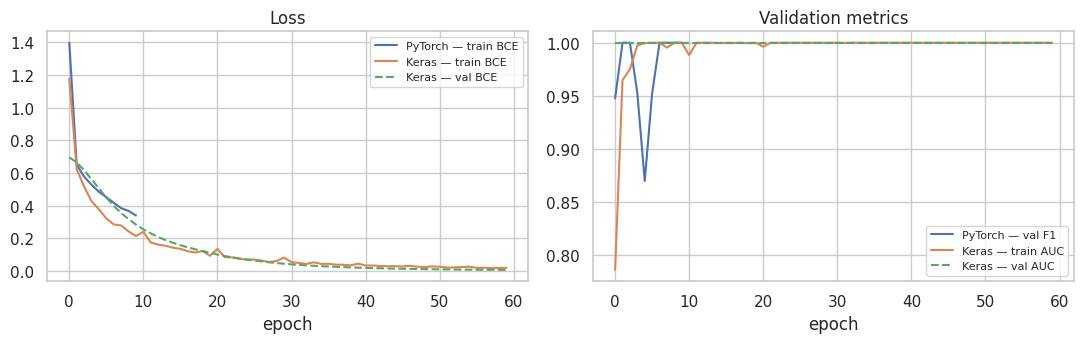

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history["train_loss"], label="PyTorch — train BCE")
axes[0].plot(history_k.history["loss"], label="Keras — train BCE")
axes[0].plot(history_k.history["val_loss"], label="Keras — val BCE", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend(fontsize=8)

axes[1].plot(history["val_f1"], label="PyTorch — val F1")
axes[1].plot(history_k.history["auc"], label="Keras — train AUC")
axes[1].plot(history_k.history["val_auc"], label="Keras — val AUC", linestyle="--")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=8)

fig.tight_layout()


## Conclusions

- Both frameworks reproduce the same architecture and reach comparable
  validation F1 / AUC, modulo random initialisation and the slight
  difference between PyTorch's `BCEWithLogitsLoss(pos_weight=...)` and
  Keras's `class_weight=`.
- Saved artifacts:
  - `models/mlp_pytorch.pt` (state-dict + meta)
  - `models/mlp_keras.keras` (full Keras SavedModel)
  - `models/mlp_scaler.joblib` (shared MinMax scaler)
- The deeper sequence model in **`05_deep_learning_sequence.ipynb`** trains
  on synthetic mouse / keystroke streams to evaluate behavioural-biometric
  inputs, which the tabular MLP cannot consume.
